# 🍽️ Bengaluru Zomato Restaurant Analytics & Machine Learning

## Project Overview

This project presents an end-to-end analysis of Bengaluru restaurants listed on Zomato. The analysis explores restaurant locations, restaurant chains, restaurant types, cuisines, ratings, customer votes, pricing, online ordering, and table-booking availability.

The project combines data cleaning, exploratory data analysis (EDA), relationship analysis, geographic analysis, feature selection, and Machine Learning.

### Objectives

- Understand the structure and quality of the Zomato restaurant dataset.
- Identify restaurant-dense locations and major restaurant chains.
- Analyze popular restaurant and cuisine types.
- Study restaurant ratings, votes, and pricing distributions.
- Compare restaurants based on online ordering and table-booking availability.
- Explore relationships between ratings, votes, cost, and online ordering.
- Analyze important predictors of restaurant ratings.
- Build models to predict restaurant ratings.
- Classify highly rated restaurants.
- Segment restaurants using K-Means clustering.

> **Note:** This notebook contains the analysis and modeling workflow. Numerical conclusions should be interpreted from the outputs generated after running the notebook.

## 1. Business Questions

This analysis aims to answer:

1. Which locations in Bengaluru have the highest concentration of restaurants?
2. Which restaurant chains have the largest presence?
3. What are the most common restaurant types?
4. Which cuisines are most popular?
5. What is the typical cost of a meal for two people?
6. Which restaurants are the most and least expensive?
7. How are restaurant ratings distributed?
8. Which restaurants receive the highest number of customer votes?
9. Is there a relationship between ratings and customer votes?
10. Does restaurant pricing differ between restaurants with and without online ordering?
11. How common is table booking among restaurants?
12. Which features are most informative for predicting restaurant ratings?
13. Can restaurant ratings be predicted using restaurant characteristics?
14. Can highly rated restaurants be identified using classification?
15. Can restaurants be grouped into meaningful segments using rating, popularity, and pricing?

## 2. Import Libraries

In [45]:
%pip install folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import folium

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    ExtraTreesRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix
)

from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

## 3. Load the Dataset

Update the path below if the CSV file is stored somewhere else.

In [5]:
df = pd.read_csv("C:/Users/chatu/Desktop/Zomato/Data/zomato.csv")

df.head(2)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


## 4. Initial Dataset Inspection

Before cleaning, inspect the dataset dimensions, data types, missing values, and duplicate records.

In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Total data points: {df.shape[0] * df.shape[1]:,}")

Rows: 51,717
Columns: 17
Total data points: 879,189


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

dish_liked                     28078
rate                            7775
phone                           1208
approx_cost(for two people)      346
rest_type                        227
cuisines                          45
location                          21
dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 5. Data Preprocessing

The raw dataset contains fields that are not required for this analysis, duplicate records, missing values, and non-numeric representations of ratings and cost.

### Preprocessing steps

- Remove URL, phone, and dish-liked fields because they are not required for this project.
- Remove duplicate rows.
- Remove rows containing missing values for the EDA dataset.
- Convert restaurant ratings from values such as `4.1/5` to numeric values.
- Convert approximate cost for two people to numeric format.

In [10]:
# Remove columns that are not required for this analysis
columns_to_drop = ["url", "phone", "dish_liked"]

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Shape after removing unnecessary columns:", df.shape)

Shape after removing unnecessary columns: (51717, 14)


In [11]:
# Remove duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 43
Shape after removing duplicates: (51674, 14)


In [12]:
# Clean restaurant ratings
df["rate"] = (
    df["rate"]
    .astype(str)
    .str.replace("/5", "", regex=False)
    .replace(["NEW", "-"], np.nan)
)

df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

In [13]:
# Clean approximate cost for two people
df["approx_cost(for two people)"] = (
    df["approx_cost(for two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"],
    errors="coerce"
)

In [14]:
# Convert votes to numeric
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")

In [15]:
# Remove rows with missing values for the EDA dataset
df = df.dropna(how="any").copy()

print("Final EDA dataset shape:", df.shape)

Final EDA dataset shape: (41237, 14)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41237 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      41237 non-null  object 
 1   name                         41237 non-null  object 
 2   online_order                 41237 non-null  object 
 3   book_table                   41237 non-null  object 
 4   rate                         41237 non-null  float64
 5   votes                        41237 non-null  int64  
 6   location                     41237 non-null  object 
 7   rest_type                    41237 non-null  object 
 8   cuisines                     41237 non-null  object 
 9   approx_cost(for two people)  41237 non-null  float64
 10  reviews_list                 41237 non-null  object 
 11  menu_item                    41237 non-null  object 
 12  listed_in(type)              41237 non-null  object 
 13  listed_in(city)      

In [17]:
df.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


## 6. Basic Restaurant Overview

In [18]:
print("Unique restaurants:", df["name"].nunique())
print("Unique locations:", df["location"].nunique())
print("Unique restaurant types:", df["rest_type"].nunique())
print("Unique cuisine entries:", df["cuisines"].nunique())

Unique restaurants: 6602
Unique locations: 92
Unique restaurant types: 87
Unique cuisine entries: 2367


In [19]:
df["name"].value_counts().head(20)

name
Cafe Coffee Day      86
Onesta               85
Empire Restaurant    69
Kanti Sweets         68
Five Star Chicken    68
Just Bake            67
Baskin Robbins       62
Pizza Hut            60
KFC                  60
Petoo                60
Smoor                59
Domino's Pizza       59
McDonald's           59
Subway               59
Sweet Truth          58
Polar Bear           58
Faasos               56
Beijing Bites        56
Burger King          55
Keventers            54
Name: count, dtype: int64

# 7. Exploratory Data Analysis

## 7.1 Restaurant Distribution by Location

The first location analysis shows the number of restaurant listings across Bengaluru locations.

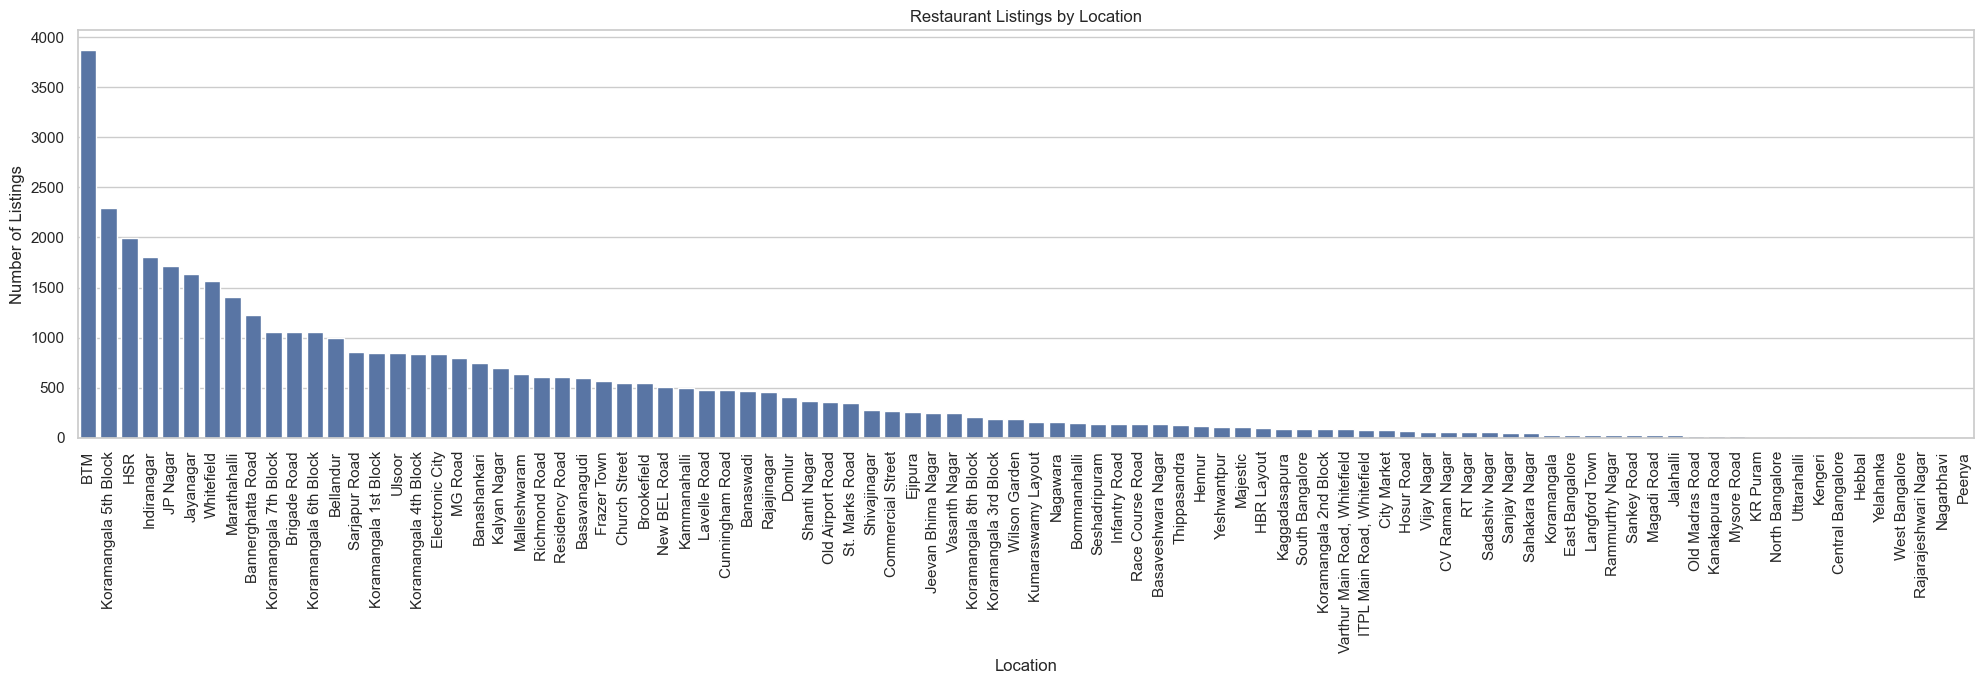

In [20]:
location_counts = df["location"].value_counts()

plt.figure(figsize=(20, 7))
sns.barplot(x=location_counts.index, y=location_counts.values)

plt.xticks(rotation=90)
plt.xlabel("Location")
plt.ylabel("Number of Listings")
plt.title("Restaurant Listings by Location")

plt.tight_layout()
plt.show()

### Top 20 Locations by Number of Restaurants

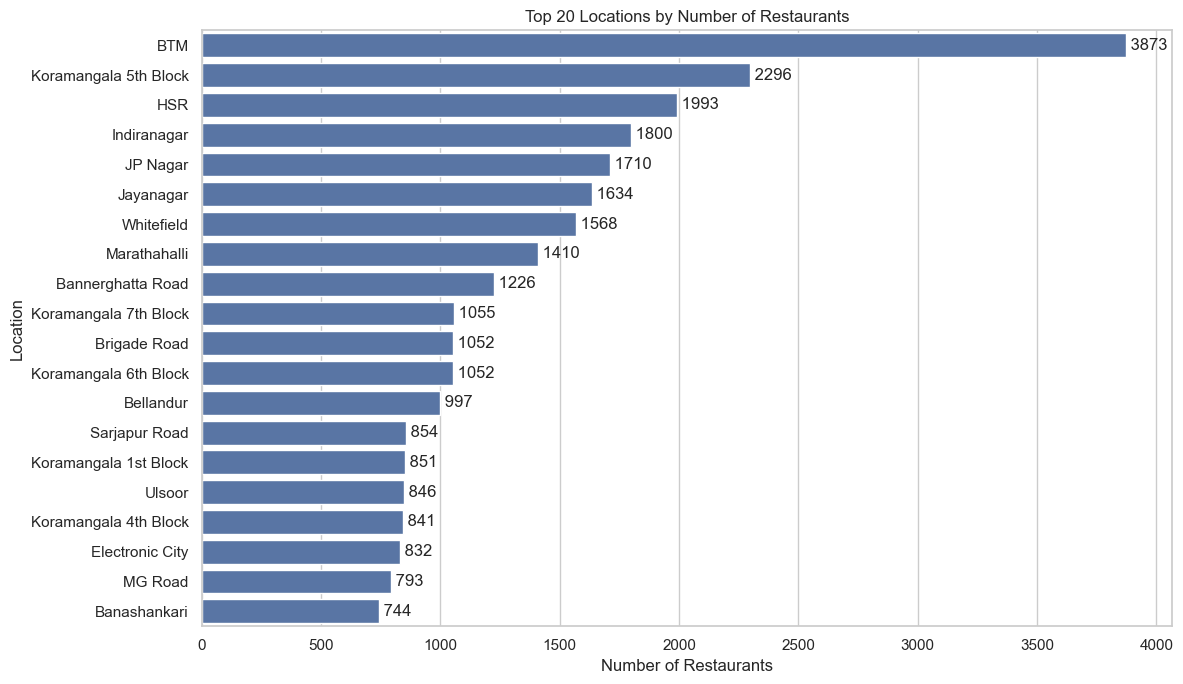

In [21]:
top_locations = df["location"].value_counts().head(20)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=top_locations.values, y=top_locations.index)

for i, value in enumerate(top_locations.values):
    ax.text(value, i, f" {value}", va="center")

plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.title("Top 20 Locations by Number of Restaurants")

plt.tight_layout()
plt.show()

## 7.2 Top 20 Areas Listed in the Dataset

The `listed_in(city)` field is used to identify the areas with the highest number of restaurant listings.

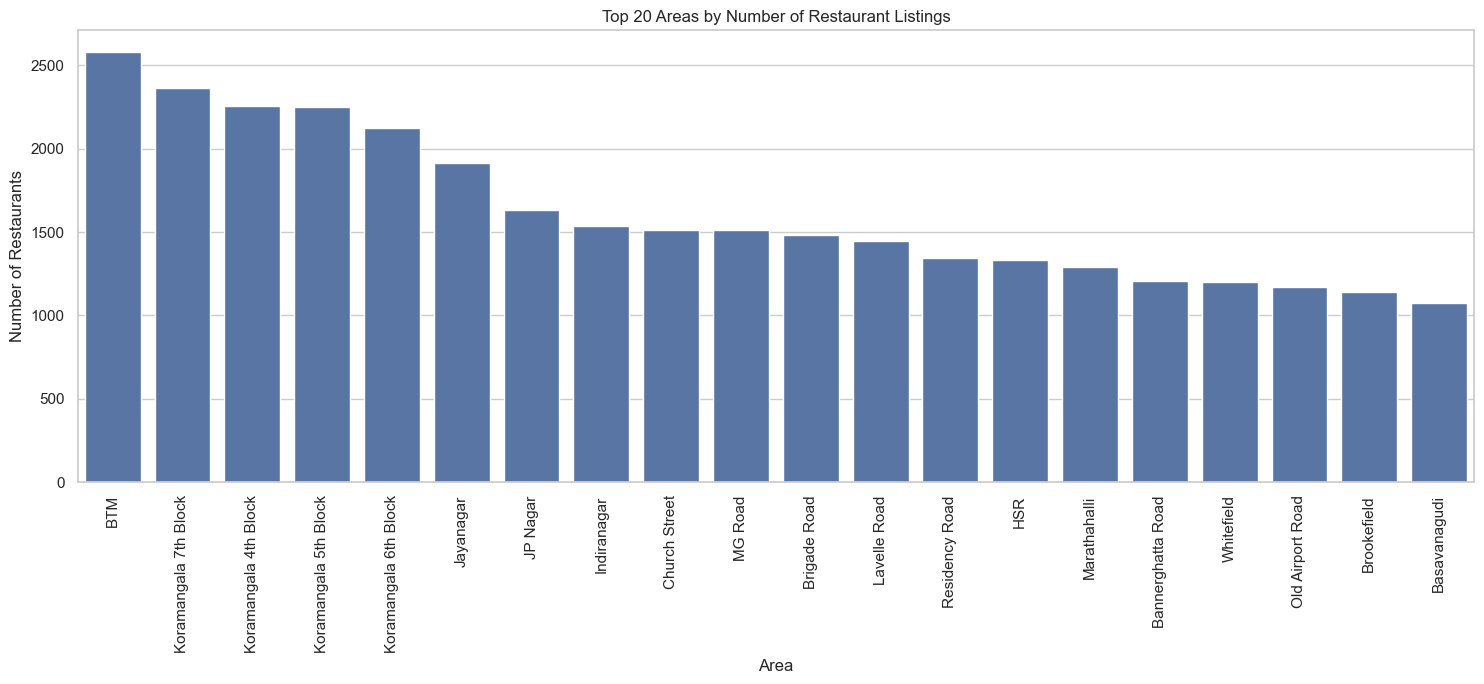

In [22]:
city_counts = df["listed_in(city)"].value_counts().head(20)

plt.figure(figsize=(15, 7))
sns.barplot(x=city_counts.index, y=city_counts.values)

plt.xticks(rotation=90)
plt.xlabel("Area")
plt.ylabel("Number of Restaurants")
plt.title("Top 20 Areas by Number of Restaurant Listings")

plt.tight_layout()
plt.show()

## 7.3 Restaurant Chains

The following analysis identifies restaurant names with the largest number of outlets in the dataset.

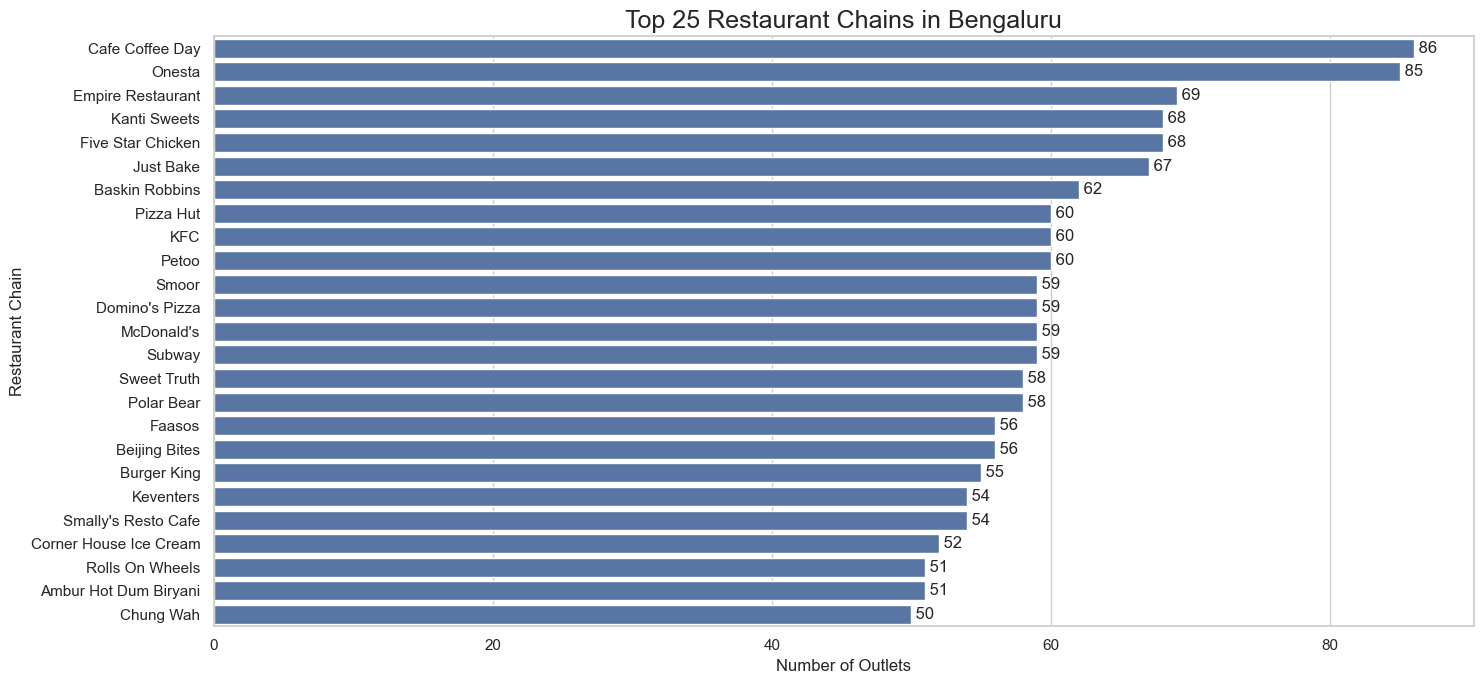

In [23]:
chains = df["name"].value_counts().head(25)

plt.figure(figsize=(15, 7))
ax = sns.barplot(x=chains.values, y=chains.index)

for i, value in enumerate(chains.values):
    ax.text(value, i, f" {value}", va="center")

plt.title("Top 25 Restaurant Chains in Bengaluru", fontsize=18)
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Chain")

plt.tight_layout()
plt.show()

## 7.4 Most Voted Restaurants

Customer votes are used as an indicator of customer engagement and popularity.

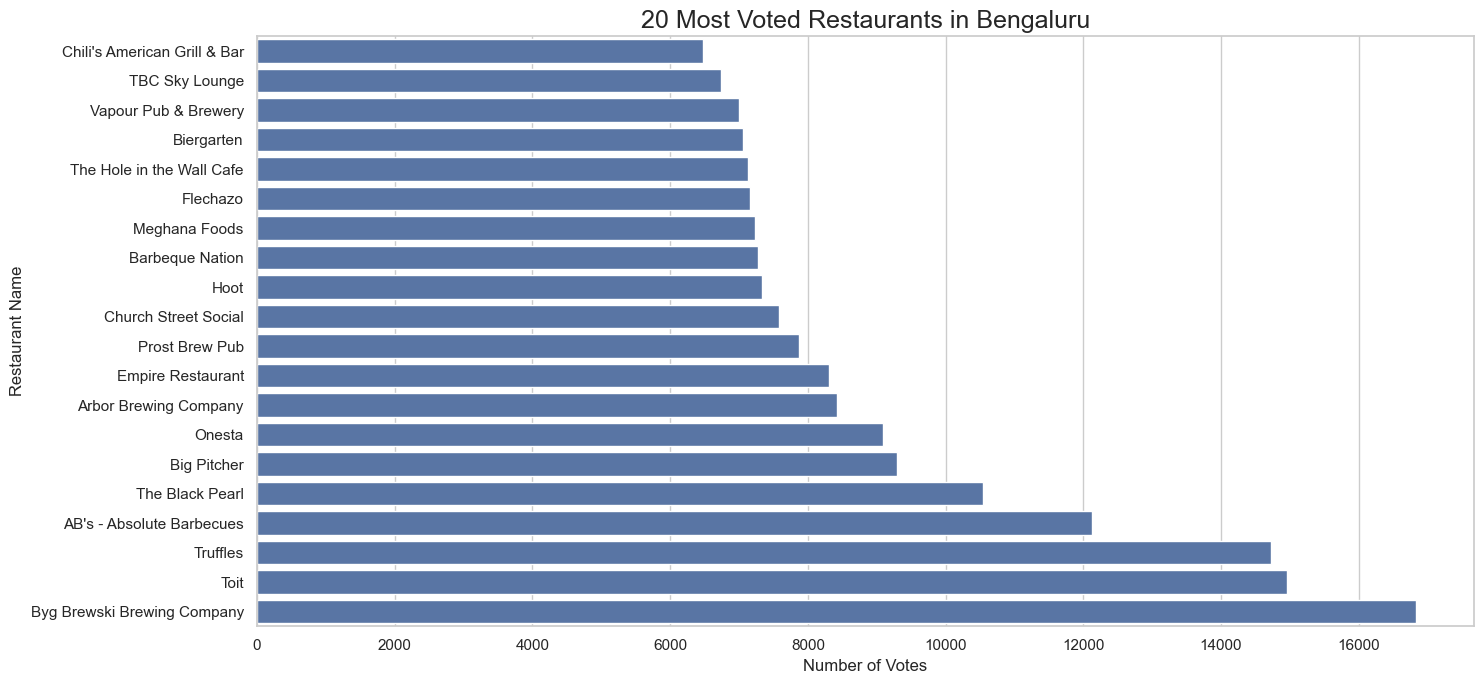

In [24]:
votes = (
    df.groupby("name")["votes"]
    .max()
    .nlargest(20)
    .sort_values()
)

plt.figure(figsize=(15, 7))
sns.barplot(x=votes.values, y=votes.index)

plt.title("20 Most Voted Restaurants in Bengaluru", fontsize=18)
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant Name")

plt.tight_layout()
plt.show()

## 7.5 Most Expensive Restaurants

Restaurants with the highest recorded approximate cost for two people are shown below.

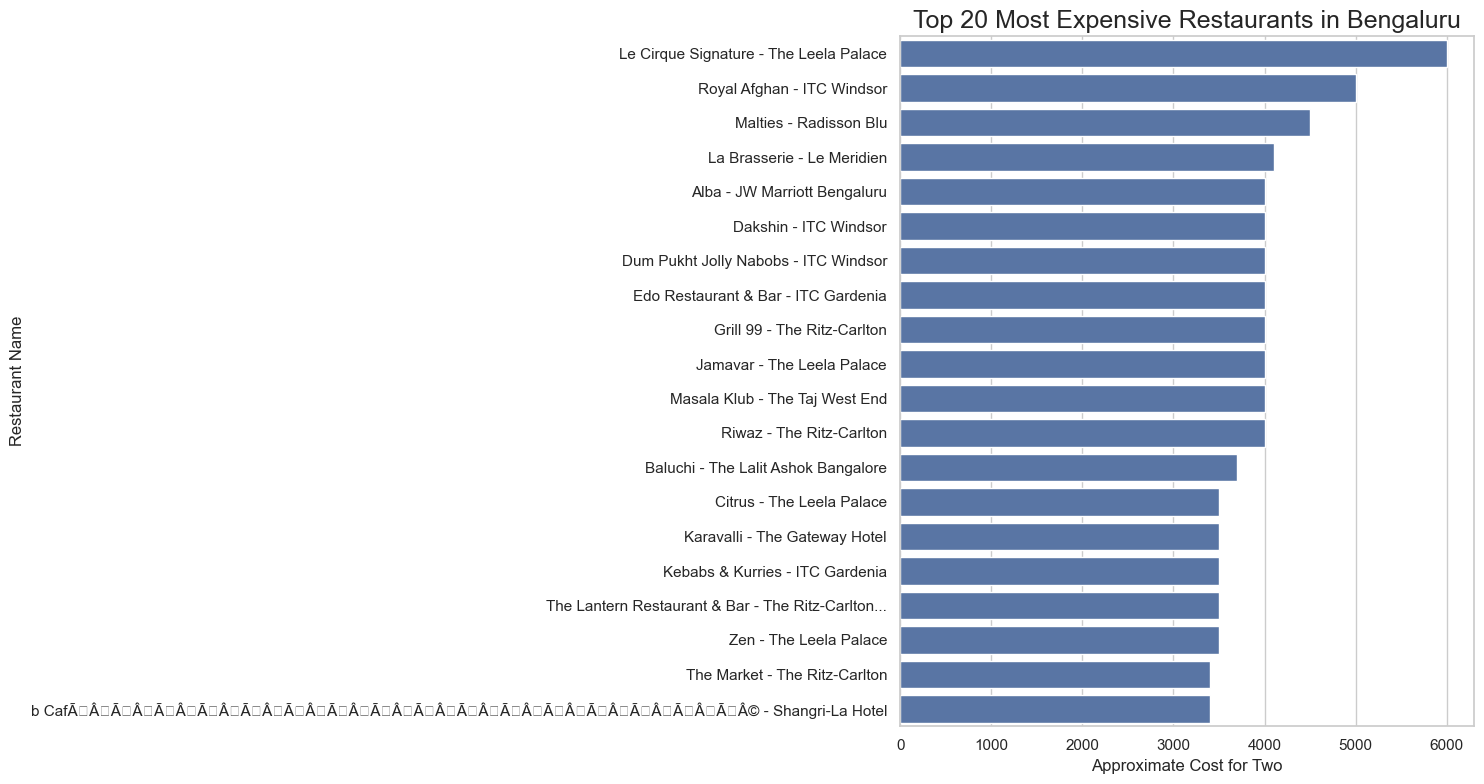

In [25]:
expensive = (
    df.groupby("name")["approx_cost(for two people)"]
    .max()
    .nlargest(20)
)

plt.figure(figsize=(15, 8))
sns.barplot(x=expensive.values, y=expensive.index)

plt.title("Top 20 Most Expensive Restaurants in Bengaluru", fontsize=18)
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Restaurant Name")

plt.tight_layout()
plt.show()

## 7.6 Least Expensive Restaurants

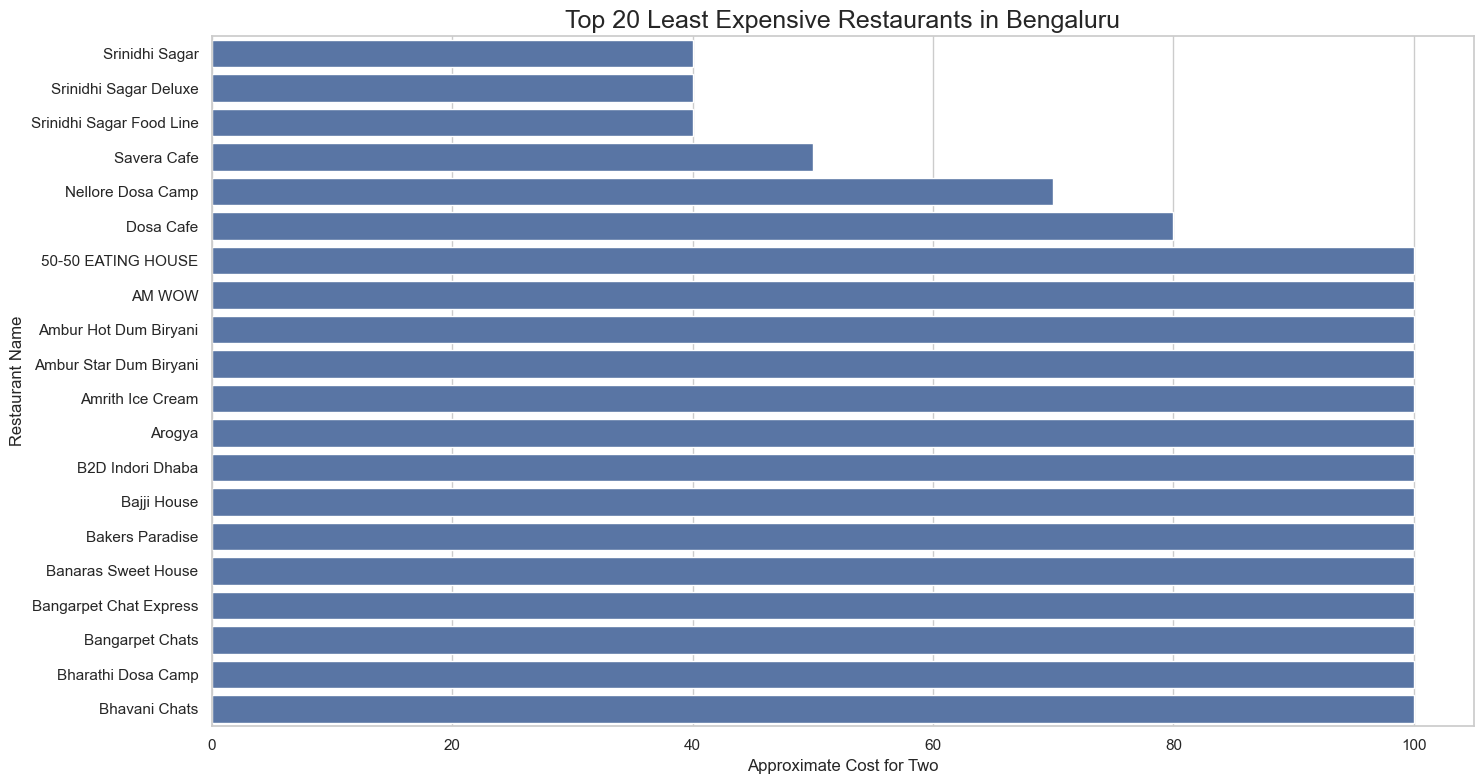

In [26]:
cheap = (
    df.groupby("name")["approx_cost(for two people)"]
    .min()
    .nsmallest(20)
)

plt.figure(figsize=(15, 8))
sns.barplot(x=cheap.values, y=cheap.index)

plt.title("Top 20 Least Expensive Restaurants in Bengaluru", fontsize=18)
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Restaurant Name")

plt.tight_layout()
plt.show()

## 7.7 Restaurant Listing and Restaurant Type

In [28]:
print("Restaurant listing types:")
display(df["listed_in(type)"].value_counts())

print("Restaurant types:")
display(df["rest_type"].value_counts().head(20))

Restaurant listing types:


listed_in(type)
Delivery              20431
Dine-out              14062
Desserts               2709
Cafes                  1511
Drinks & nightlife     1045
Buffet                  847
Pubs and bars           632
Name: count, dtype: int64

Restaurant types:


rest_type
Quick Bites                   13871
Casual Dining                  9608
Cafe                           3368
Dessert Parlor                 1850
Delivery                       1666
Takeaway, Delivery             1278
Casual Dining, Bar             1092
Bakery                          704
Bar                             640
Beverage Shop                   639
Food Court                      498
Bar, Casual Dining              385
Lounge                          381
Pub                             351
Sweet Shop                      346
Fine Dining                     342
Casual Dining, Cafe             310
Beverage Shop, Quick Bites      239
Pub, Casual Dining              236
Bakery, Quick Bites             225
Name: count, dtype: int64

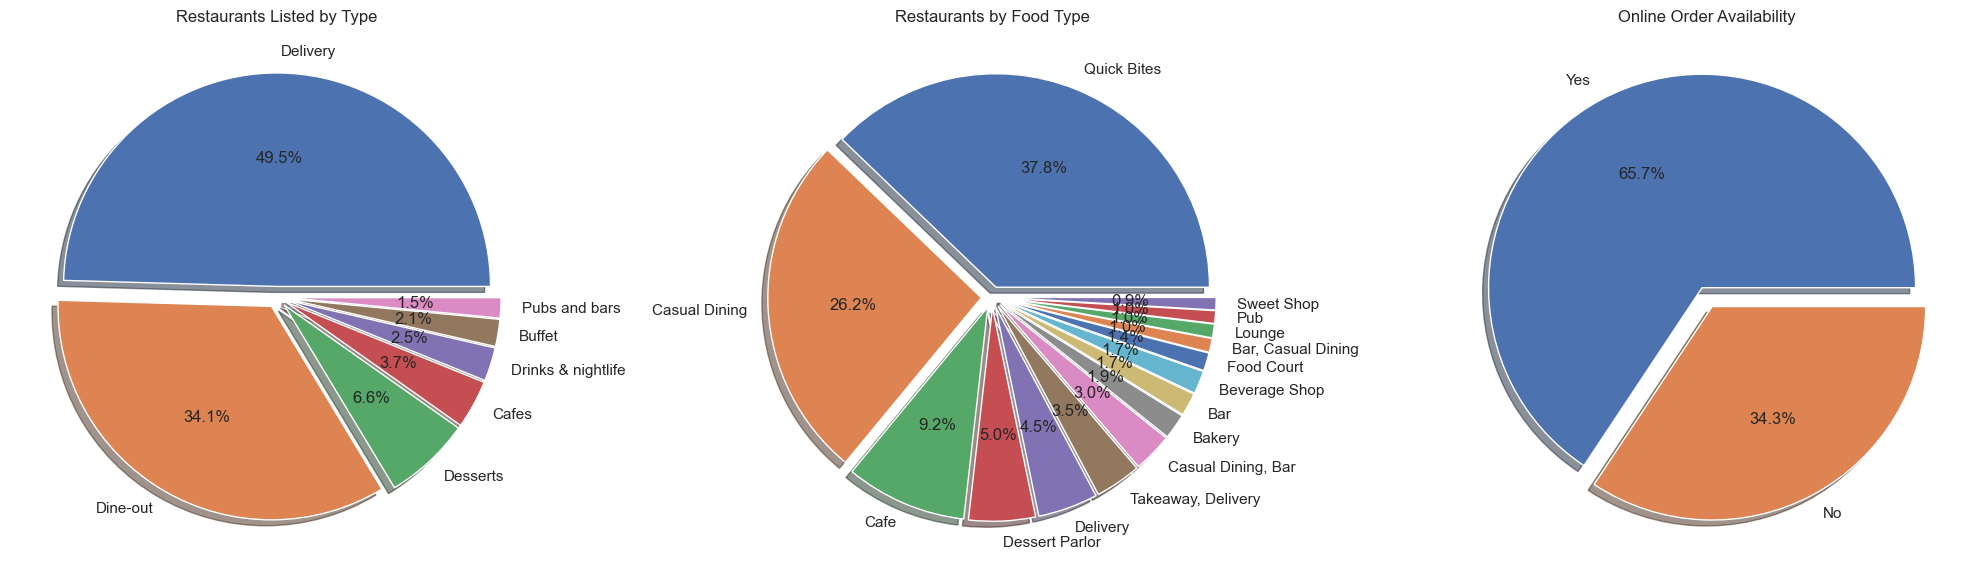

In [29]:
plt.figure(figsize=(20, 7))

# Restaurant listing type
plt.subplot(1, 3, 1)
data = df["listed_in(type)"].value_counts()

plt.pie(
    data,
    labels=data.index,
    autopct="%1.1f%%",
    explode=[0.05] * len(data),
    shadow=True
)
plt.title("Restaurants Listed by Type")

# Restaurant type
plt.subplot(1, 3, 2)
data = df["rest_type"].value_counts().head(15)

plt.pie(
    data,
    labels=data.index,
    autopct="%1.1f%%",
    explode=[0.05] * len(data),
    shadow=True
)
plt.title("Restaurants by Food Type")

# Online order
plt.subplot(1, 3, 3)
data = df["online_order"].value_counts()

plt.pie(
    data,
    labels=data.index,
    autopct="%1.1f%%",
    explode=[0.05] * len(data),
    shadow=True
)
plt.title("Online Order Availability")

plt.tight_layout()
plt.show()

## 7.8 Online Ordering and Table Booking

The following comparison shows how many restaurants accept online orders and how many provide table booking.

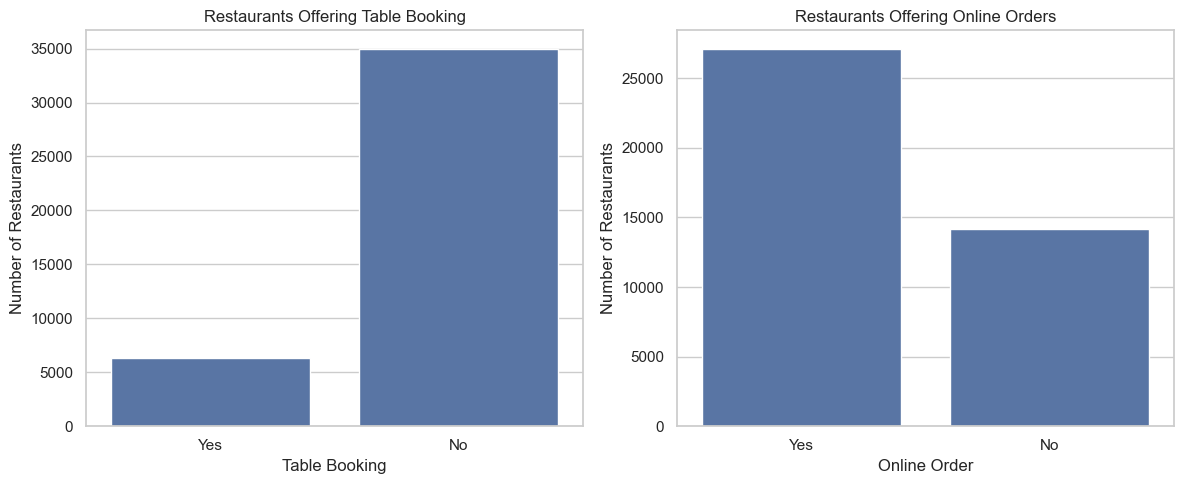

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x="book_table", data=df)
plt.title("Restaurants Offering Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Number of Restaurants")

plt.subplot(1, 2, 2)
sns.countplot(x="online_order", data=df)
plt.title("Restaurants Offering Online Orders")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

## 7.9 Most Popular Cuisines

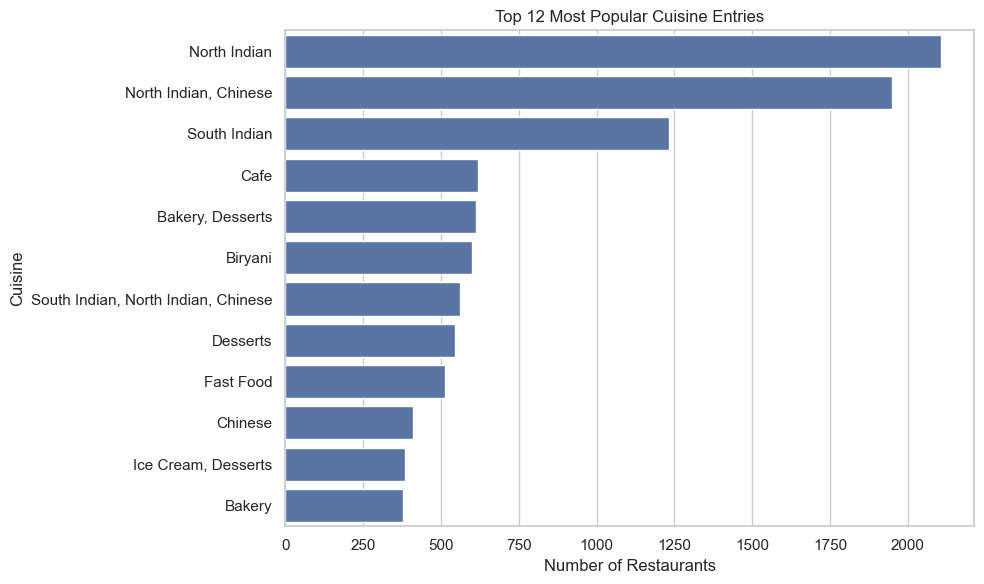

In [31]:
top_cuisines = df["cuisines"].value_counts().head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.title("Top 12 Most Popular Cuisine Entries")

plt.tight_layout()
plt.show()

## 7.10 Cost of a Meal for Two

The cost distribution is examined using a histogram with KDE and a box plot. The box plot helps identify potential outliers.

In [32]:
print(
    "Mean cost for two people:",
    round(df["approx_cost(for two people)"].mean(), 2)
)
print(
    "Median cost for two people:",
    round(df["approx_cost(for two people)"].median(), 2)
)

Mean cost for two people: 603.91
Median cost for two people: 500.0


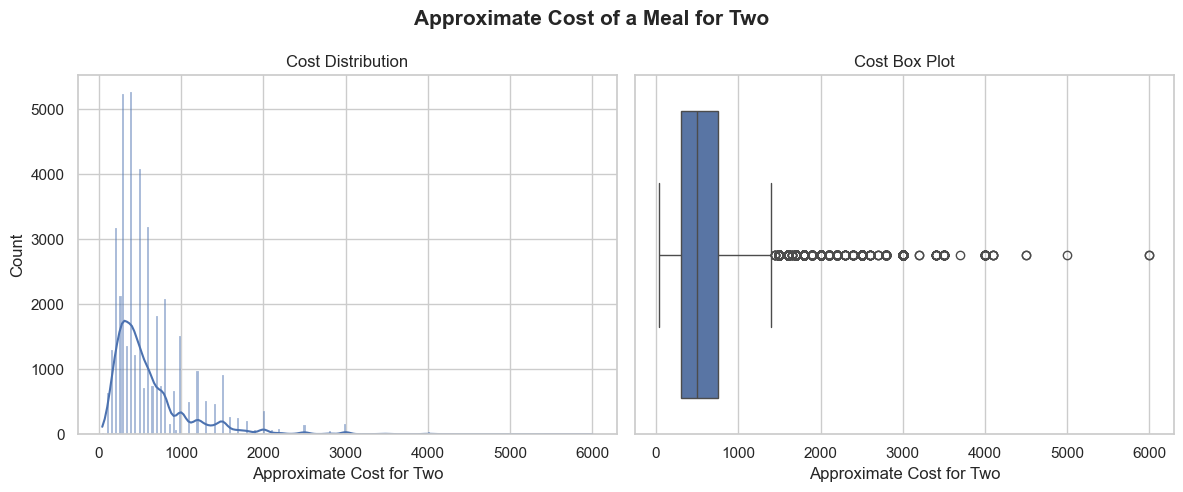

In [33]:
plt.figure(figsize=(12, 5))
plt.suptitle("Approximate Cost of a Meal for Two", fontweight="bold", fontsize=15)

plt.subplot(1, 2, 1)
sns.histplot(df["approx_cost(for two people)"], kde=True)
plt.title("Cost Distribution")
plt.xlabel("Approximate Cost for Two")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["approx_cost(for two people)"])
plt.title("Cost Box Plot")
plt.xlabel("Approximate Cost for Two")

plt.tight_layout()
plt.show()

## 7.11 Customer Votes

Votes are analyzed using a distribution plot and box plot. Customer vote counts are generally useful for understanding engagement and popularity.

In [34]:
print("Median votes:", df["votes"].median())
print("Maximum votes:", df["votes"].max())

Median votes: 73.0
Maximum votes: 16832


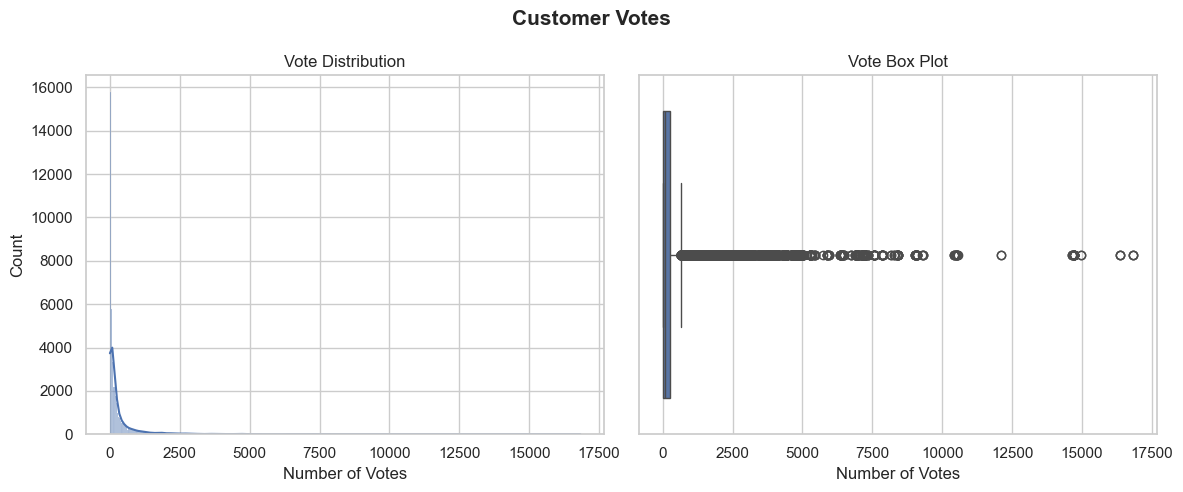

In [35]:
plt.figure(figsize=(12, 5))
plt.suptitle("Customer Votes", fontweight="bold", fontsize=15)

plt.subplot(1, 2, 1)
sns.histplot(df["votes"], kde=True)
plt.title("Vote Distribution")
plt.xlabel("Number of Votes")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["votes"])
plt.title("Vote Box Plot")
plt.xlabel("Number of Votes")

plt.tight_layout()
plt.show()

## 7.12 Restaurant Ratings

Restaurant ratings are analyzed using a distribution plot and box plot.

In [36]:
print("Mean rating:", round(df["rate"].mean(), 2))
print("Median rating:", round(df["rate"].median(), 2))

Mean rating: 3.7
Median rating: 3.7


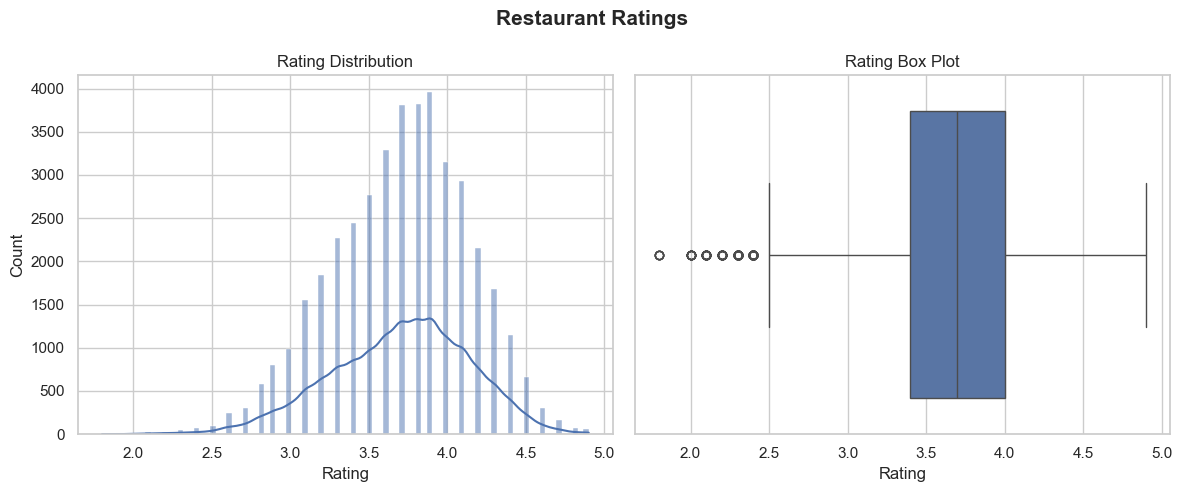

In [37]:
plt.figure(figsize=(12, 5))
plt.suptitle("Restaurant Ratings", fontweight="bold", fontsize=15)

plt.subplot(1, 2, 1)
sns.histplot(df["rate"], kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["rate"])
plt.title("Rating Box Plot")
plt.xlabel("Rating")

plt.tight_layout()
plt.show()

# 8. Relationship Analysis

This section examines relationships between restaurant ratings, votes, cost, and online ordering.

## 8.1 Rating vs Cost

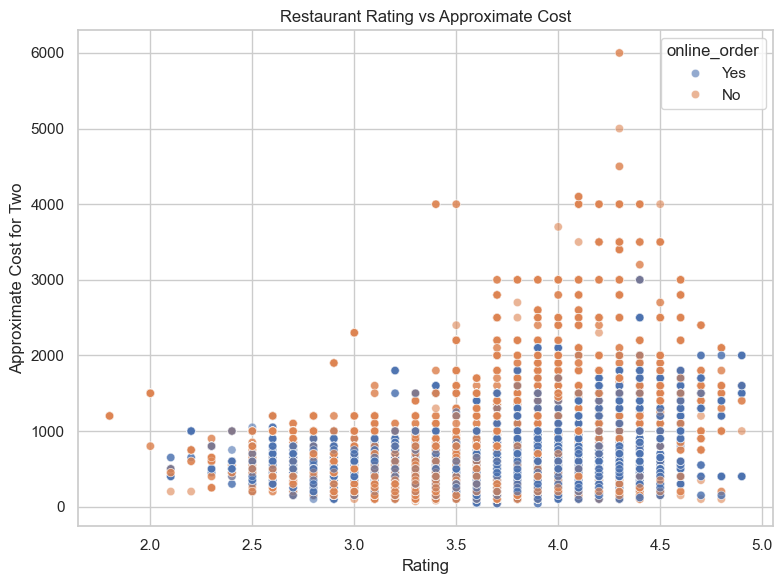

In [38]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="rate",
    y="approx_cost(for two people)",
    hue="online_order",
    data=df,
    alpha=0.6
)

plt.title("Restaurant Rating vs Approximate Cost")
plt.xlabel("Rating")
plt.ylabel("Approximate Cost for Two")

plt.tight_layout()
plt.show()

## 8.2 Rating vs Votes

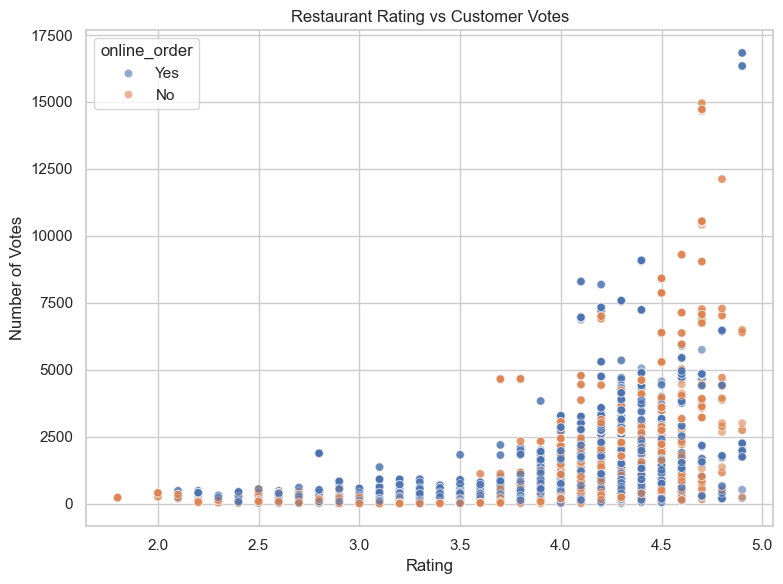

In [39]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="rate",
    y="votes",
    hue="online_order",
    data=df,
    alpha=0.6
)

plt.title("Restaurant Rating vs Customer Votes")
plt.xlabel("Rating")
plt.ylabel("Number of Votes")

plt.tight_layout()
plt.show()

## 8.3 Votes by Online Ordering Availability

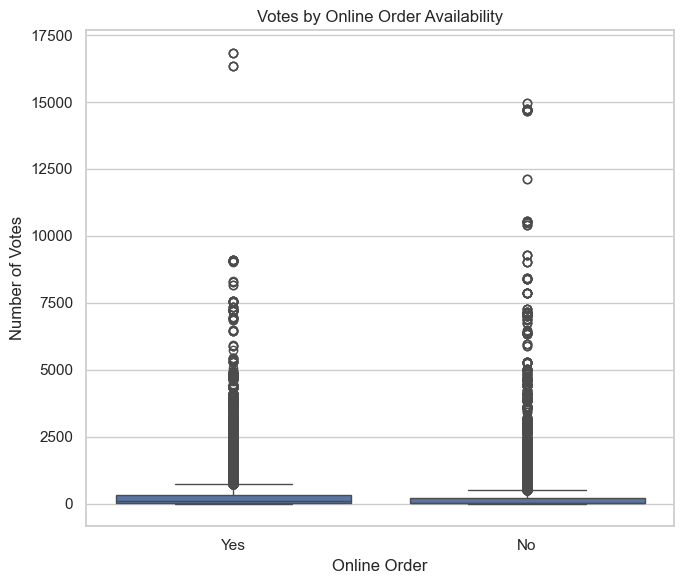

In [40]:
plt.figure(figsize=(7, 6))

sns.boxplot(
    x="online_order",
    y="votes",
    data=df
)

plt.title("Votes by Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Number of Votes")

plt.tight_layout()
plt.show()

## 8.4 Cost by Online Ordering Availability

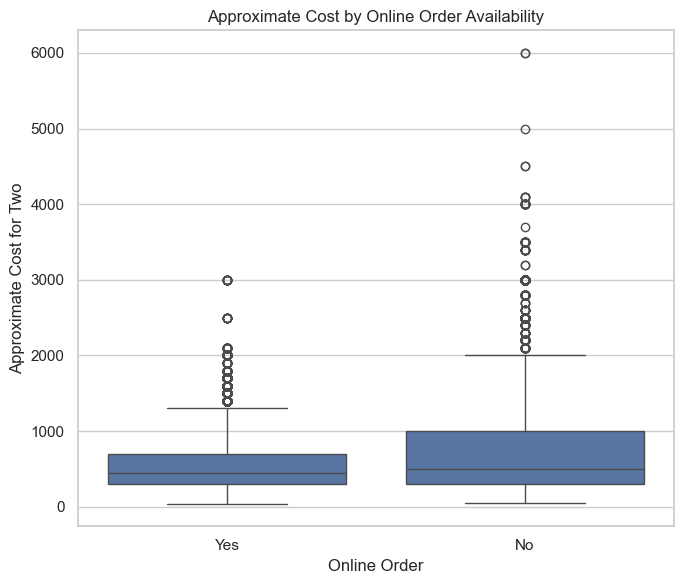

In [41]:
plt.figure(figsize=(7, 6))

sns.boxplot(
    x="online_order",
    y="approx_cost(for two people)",
    data=df
)

plt.title("Approximate Cost by Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Approximate Cost for Two")

plt.tight_layout()
plt.show()

# 9. Geographic Analysis

Restaurant locations can be enriched with latitude and longitude and visualized on an interactive Bengaluru map.

The recommended workflow is to geocode **unique locations**, not every restaurant record, because many restaurants share the same location.

In [42]:
# Create a location-level restaurant count table
Rest_locations = pd.DataFrame(
    df["location"].value_counts().reset_index()
)

Rest_locations.columns = ["Name", "count"]

Rest_locations.head()

,Name,count
0,BTM,3873
1,Koramangala 5th Block,2296
2,HSR,1993
3,Indiranagar,1800
4,JP Nagar,1710


### Geocoding

If a `locations` DataFrame containing `Name`, `latitude`, and `longitude` has already been created, it can be merged with the restaurant counts.

The geocoding process itself is intentionally kept separate from the main EDA because it requires external geocoding requests.

In [43]:
# Expected columns in locations:
# Name, latitude, longitude

# Example:
# Restaurant_locations = Rest_locations.merge(
#     locations,
#     on="Name",
#     how="left"
# ).dropna(subset=["latitude", "longitude"])

In [47]:
# Optional Folium map once coordinates are available

import folium

def generateBaseMap(
    default_location=[12.97, 77.59],
    default_zoom_start=12
):
    return folium.Map(
        location=default_location,
        zoom_start=default_zoom_start
    )

In [48]:
# Example map:
#
# base_map = generateBaseMap()
#
# for _, row in Restaurant_locations.iterrows():
#     folium.CircleMarker(
#         location=[row["latitude"], row["longitude"]],
#         radius=5,
#         popup=f'{row["Name"]} - {row["count"]} restaurants',
#         fill=True
#     ).add_to(base_map)
#
# base_map

# 10. Machine Learning Preparation

The EDA is followed by Machine Learning to investigate whether restaurant attributes can be used to predict ratings and identify highly rated restaurants.

The ML workflow uses a separate `ml_df` so that the exploratory dataset remains available for analysis.

In [49]:
ml_df = df[
    [
        "name",
        "online_order",
        "book_table",
        "rate",
        "votes",
        "location",
        "rest_type",
        "cuisines",
        "approx_cost(for two people)"
    ]
].copy()

ml_df = ml_df.dropna(subset=["rate"])

categorical_cols = [
    "online_order",
    "book_table",
    "location",
    "rest_type",
    "cuisines"
]

for col in categorical_cols:
    ml_df[col] = ml_df[col].fillna("Unknown")

ml_df["votes"] = ml_df["votes"].fillna(ml_df["votes"].median())

ml_df["approx_cost(for two people)"] = (
    ml_df["approx_cost(for two people)"]
    .fillna(ml_df["approx_cost(for two people)"].median())
)

ml_df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0


# 11. Feature Selection

Feature selection is performed to understand which variables contain useful information about restaurant ratings.

Two approaches are retained from the original analysis:

1. Mutual Information
2. Extra Trees feature importance

A correlation heatmap is also included for numerical relationships.

In [50]:
# Encode categorical variables for exploratory feature-selection analysis
def encode_for_analysis(data):
    encoded = data.copy()

    for column in encoded.columns:
        if column not in ["rate", "approx_cost(for two people)", "votes"]:
            encoded[column] = encoded[column].factorize()[0]

    return encoded

zomato = encode_for_analysis(df)

zomato.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,0,0,0,4.1,775,0,0,0,800.0,0,0,0,0
1,1,1,0,1,4.1,787,0,0,1,800.0,1,0,0,0
2,2,2,0,1,3.8,918,0,1,2,800.0,2,0,0,0
3,3,3,1,1,3.7,88,0,2,3,300.0,3,0,0,0
4,4,4,1,1,3.8,166,1,0,4,600.0,4,0,0,0


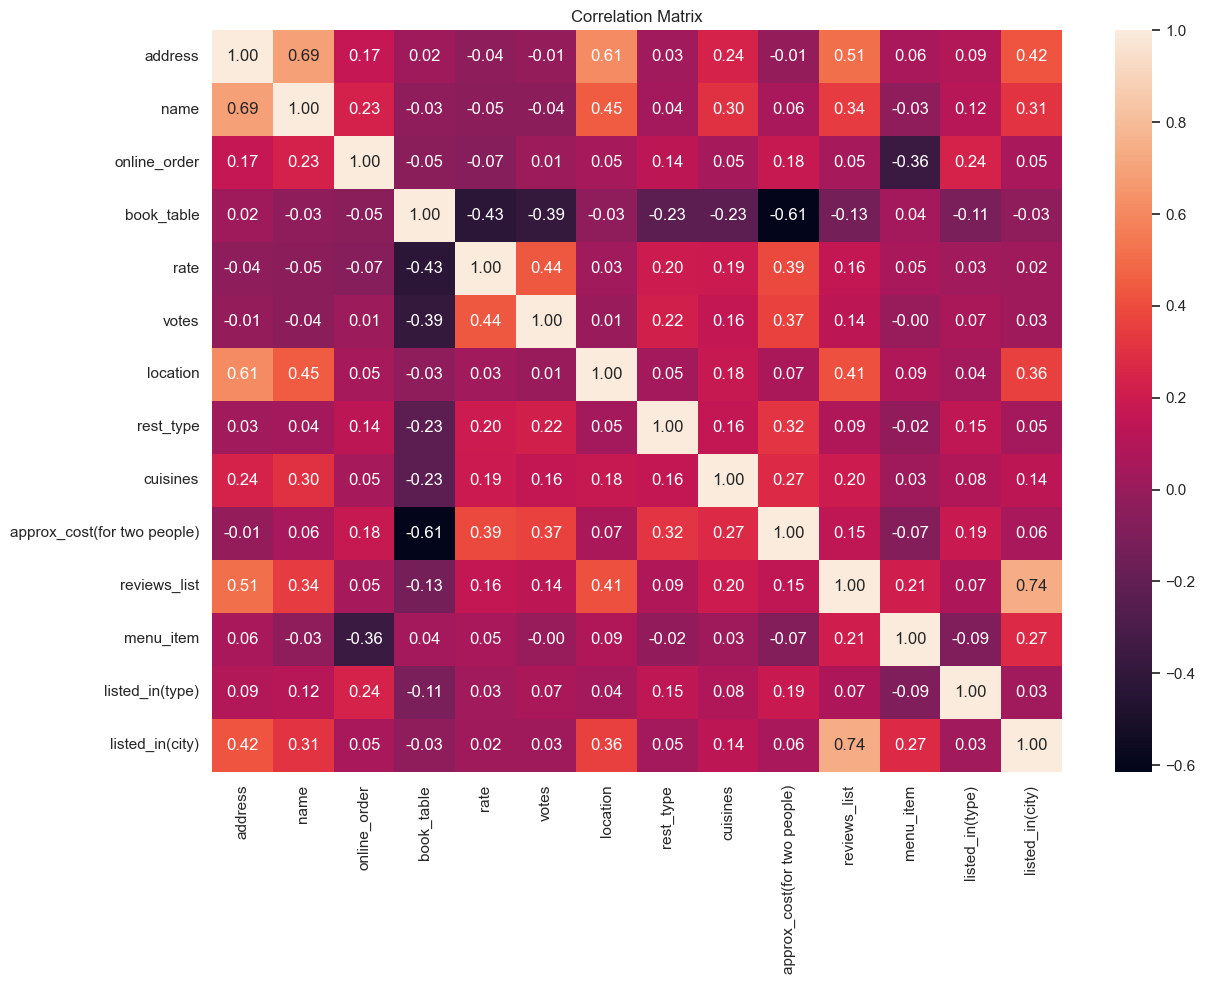

In [51]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    zomato.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

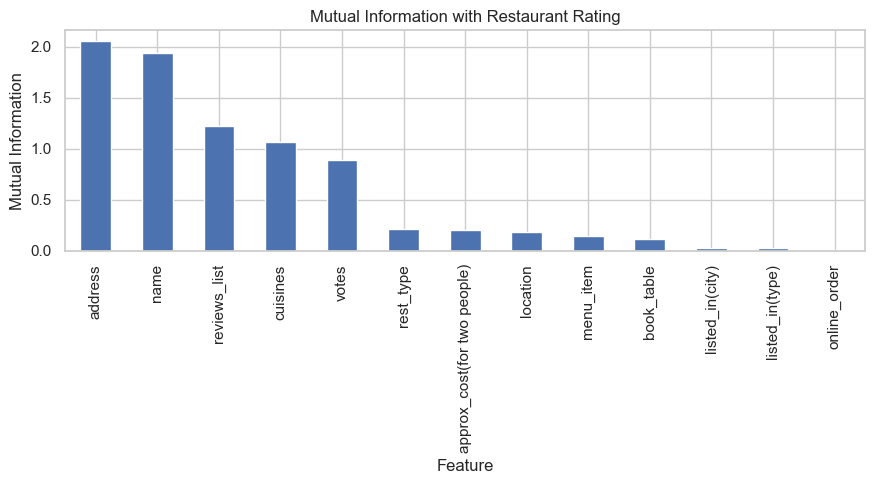

In [52]:
y = zomato["rate"]
X_fs = zomato.drop("rate", axis=1)

mi = mutual_info_regression(X_fs, y, random_state=42)

mi = pd.Series(mi, index=X_fs.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
mi.plot.bar()

plt.title("Mutual Information with Restaurant Rating")
plt.ylabel("Mutual Information")
plt.xlabel("Feature")

plt.tight_layout()
plt.show()

## Extra Trees Feature Importance

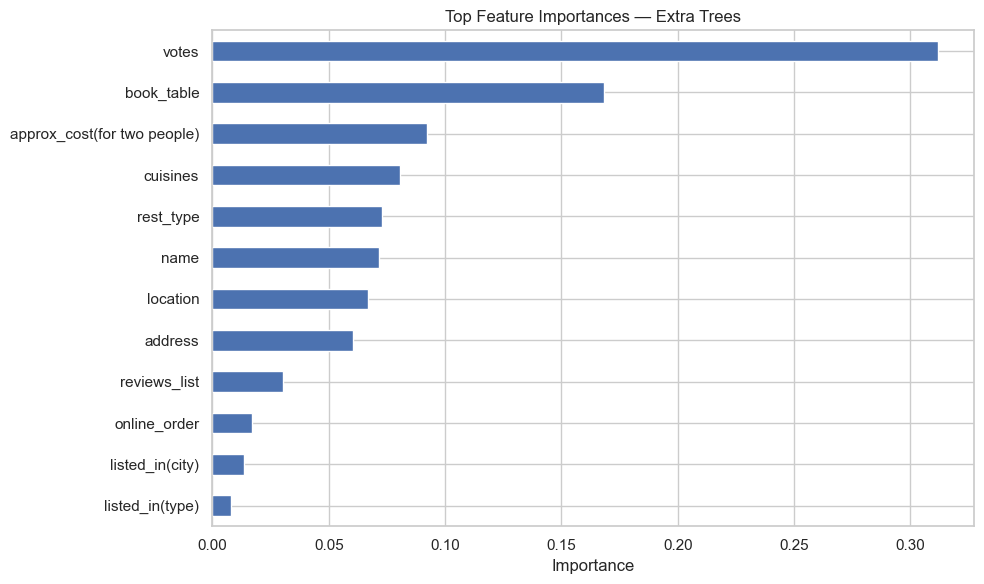

In [53]:
extra_trees = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(X_fs, y)

feature_importance = (
    pd.Series(
        extra_trees.feature_importances_,
        index=X_fs.columns
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

feature_importance.head(12).sort_values().plot(
    kind="barh"
)

plt.title("Top Feature Importances — Extra Trees")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

# 12. Restaurant Rating Prediction

## Business Question

Can restaurant characteristics such as location, restaurant type, cuisine, customer votes, pricing, online ordering, and table booking be used to predict restaurant ratings?

This is a regression problem because the target variable, `rate`, is continuous.

In [54]:
X = ml_df[
    [
        "online_order",
        "book_table",
        "votes",
        "location",
        "rest_type",
        "cuisines",
        "approx_cost(for two people)"
    ]
]

y = ml_df["rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [55]:
numeric_features = [
    "votes",
    "approx_cost(for two people)"
]

categorical_features = [
    "online_order",
    "book_table",
    "location",
    "rest_type",
    "cuisines"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(handle_unknown="ignore")
                )
            ]),
            categorical_features
        )
    ]
)

## 12.1 Linear Regression

In [56]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

## 12.2 Random Forest Regressor

In [57]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## 12.3 Gradient Boosting Regressor

In [58]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

## 12.4 Model Evaluation

In [59]:
predictions = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

results = []

for name, pred in predictions.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
).sort_values("R2", ascending=False)

results_df

,Model,MAE,RMSE,R2
1,Random Forest,0.044706,0.112982,0.933766
0,Linear Regression,0.206000,0.288661,0.567642
2,Gradient Boosting,0.211857,0.289665,0.564631


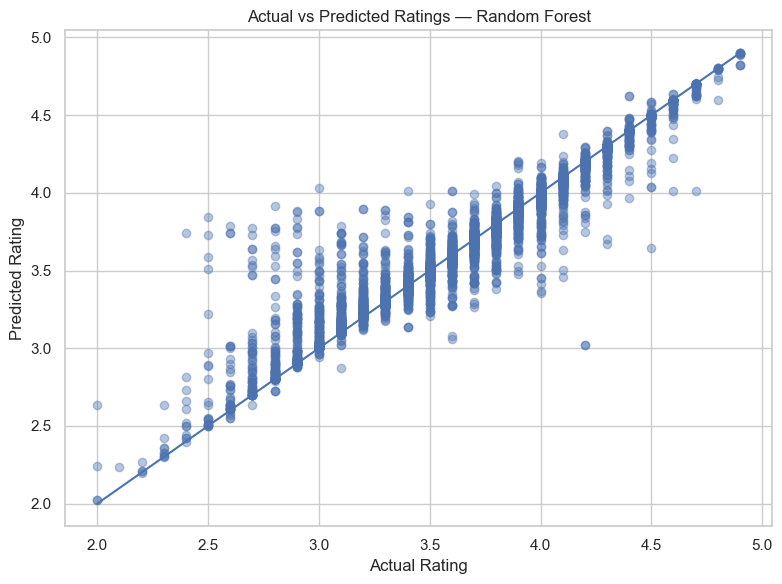

In [60]:
best_model_name = results_df.iloc[0]["Model"]

prediction_lookup = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

best_pred = prediction_lookup[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(f"Actual vs Predicted Ratings — {best_model_name}")

plt.tight_layout()
plt.show()

# 13. Predict Highly Rated Restaurants

## Business Question

Can restaurant characteristics be used to identify restaurants likely to have a rating of 4.0 or higher?

The target is defined as:

- `1` → rating >= 4.0
- `0` → rating < 4.0

This converts the problem into binary classification.

In [61]:
ml_df["high_rating"] = (
    ml_df["rate"] >= 4.0
).astype(int)

ml_df["high_rating"].value_counts()

high_rating
0    28942
1    12295
Name: count, dtype: int64

In [62]:
X = ml_df[
    [
        "online_order",
        "book_table",
        "votes",
        "location",
        "rest_type",
        "cuisines",
        "approx_cost(for two people)"
    ]
]

y = ml_df["high_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [63]:
classifier = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5789
           1       0.99      0.97      0.98      2459

    accuracy                           0.99      8248
   macro avg       0.99      0.98      0.98      8248
weighted avg       0.99      0.99      0.99      8248



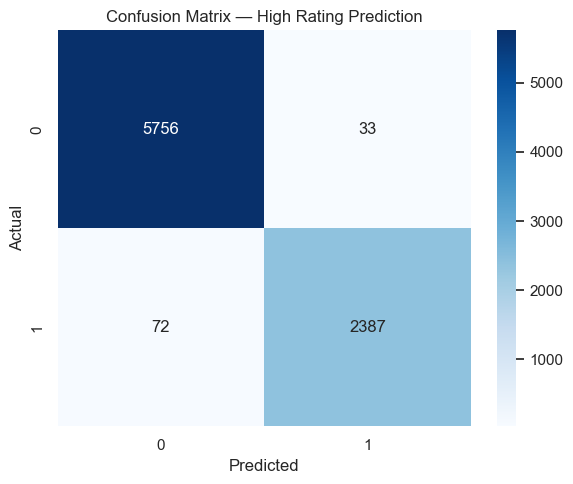

In [65]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — High Rating Prediction")

plt.tight_layout()
plt.show()

# 14. Restaurant Segmentation Using K-Means

## Objective

Restaurants are segmented using:

- Rating
- Customer votes
- Approximate cost for two people

Because vote counts can be highly skewed, a log transformation is applied before clustering.

In [66]:
cluster_df = df[
    [
        "rate",
        "votes",
        "approx_cost(for two people)"
    ]
].dropna().copy()

cluster_df["log_votes"] = np.log1p(cluster_df["votes"])

cluster_df.head()

,rate,votes,approx_cost(for two people),log_votes
0,4.1,775,800.0,6.654153
1,4.1,787,800.0,6.669498
2,3.8,918,800.0,6.823286
3,3.7,88,300.0,4.488636
4,3.8,166,600.0,5.117994


In [67]:
cluster_features = [
    "rate",
    "log_votes",
    "approx_cost(for two people)"
]

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_df[cluster_features]
)

## 14.1 Elbow Method

The elbow method is used to evaluate a range of cluster counts.

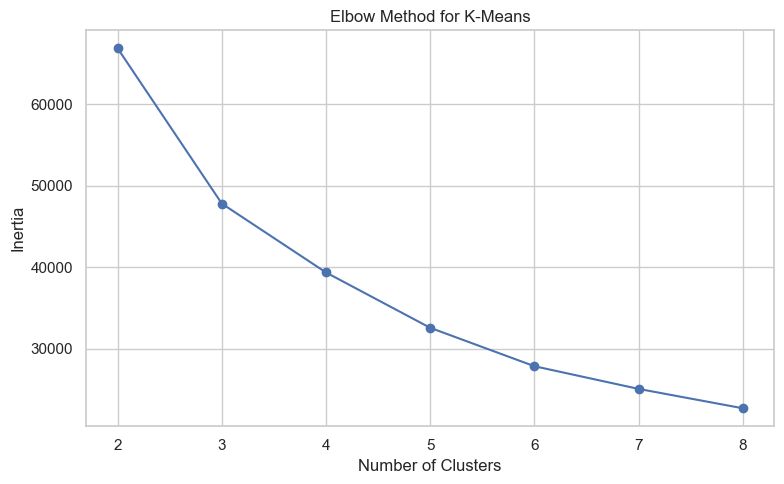

In [68]:
inertia = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_cluster)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.tight_layout()
plt.show()

## 14.2 Final K-Means Model

The original analysis used four clusters. This value can be changed after reviewing the elbow plot.

In [69]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

In [70]:
cluster_summary = (
    cluster_df
    .groupby("cluster")[
        [
            "rate",
            "votes",
            "approx_cost(for two people)"
        ]
    ]
    .mean()
)

cluster_summary

,rate,votes,approx_cost(for two people)
cluster,,,
0,4.081367,699.404918,650.715509
1,3.742404,74.961361,417.754812
2,4.201859,1386.989215,1659.775126
3,3.196412,39.386814,414.039450


# 15. Final Business Insights

After running the notebook, summarize the actual findings here.

Recommended areas to report:

### Restaurant Market
- Top restaurant-dense locations
- Largest restaurant chains
- Most common restaurant types

### Customer Preferences
- Most popular cuisine entries
- Typical restaurant rating
- Most-voted restaurants

### Pricing
- Mean and median cost for two
- Premium and budget restaurant observations
- Pricing differences by online ordering

### Service
- Online ordering availability
- Table-booking availability
- Relationship between service options and customer engagement

### Geographic
- High-density restaurant locations
- Patterns visible in the interactive map

### Machine Learning
- Best rating prediction model and its MAE, RMSE, and R²
- Classification performance for high-rated restaurants
- Characteristics of the resulting restaurant clusters

> Add numerical values from the executed outputs rather than estimating them manually.

# 16. Conclusion

This project demonstrates an end-to-end restaurant analytics workflow using the Bengaluru Zomato dataset.

The analysis progresses from raw-data inspection and cleaning to exploratory analysis, relationship analysis, geographic visualization, feature selection, supervised Machine Learning, and unsupervised clustering.

The project demonstrates practical capabilities in:

- Python
- Pandas and NumPy
- Data cleaning
- Exploratory Data Analysis
- Matplotlib and Seaborn
- Feature selection
- Scikit-learn pipelines
- Regression
- Classification
- K-Means clustering
- Geographic analysis with Folium and Geopy
- Business-oriented interpretation

The final notebook should be used together with a concise GitHub README containing the project summary, technologies, key findings, screenshots, and instructions for running the analysis.